# Análisis de algoritmo paralelo kNN

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [4]:
df  = pd.read_csv('results/knn_cluster_results.csv')
df.head()

,Processes,Subset_%,N_train,N_test,T_comp (s),T_comm (s),T_total (s),GFLOP/s,Accuracy
0,1,25,14000,3500,310.676218,0.000000,310.676218,0.370959,0.960571
1,1,50,28000,7000,1213.633262,0.000000,1213.633262,0.379845,0.964000
2,1,75,42000,10500,2725.310524,0.000000,2725.310524,0.380592,0.969333
3,1,100,56000,14000,4962.291344,0.000000,4962.291344,0.371596,0.972643
4,2,25,14000,3500,167.970559,0.121903,168.092497,0.343060,0.960571


In [5]:
t1_map = df[df['Processes'] == 1].set_index('Subset_%')['T_total (s)'].to_dict()
df['T_s_base'] = df['Subset_%'].map(t1_map)
df['Speedup'] = df['T_s_base'] / df['T_total (s)']
df['Efficiency'] = df['Speedup'] / df['Processes']

df.drop(columns=['T_s_base'], inplace=True)

df_100 = df[df['Subset_%'] == 100].copy()
df_100.reset_index(drop=True, inplace=True)

df_100

,Processes,Subset_%,N_train,N_test,T_comp (s),T_comm (s),T_total (s),GFLOP/s,Accuracy,Speedup,Efficiency
0,1,100,56000,14000,4962.291344,0.000000,4962.291344,0.371596,0.972643,1.000000,1.000000
1,2,100,56000,14000,2585.342027,0.451704,2585.793779,0.356620,0.972643,1.919059,0.959530
2,4,100,56000,14000,1330.978899,0.736158,1331.715096,0.346356,0.972643,3.726241,0.931560
3,8,100,56000,14000,831.678073,1.215826,832.893942,0.277146,0.972643,5.957891,0.744736
4,16,100,56000,14000,765.520115,3.061793,768.581966,0.150549,0.972643,6.456424,0.403527
5,32,100,56000,14000,865.840660,3.038242,868.878984,0.066629,0.972643,5.711142,0.178473


### Tiempos de ejecución $T_{comp}$, $T_{comm}$, $T_{total}$

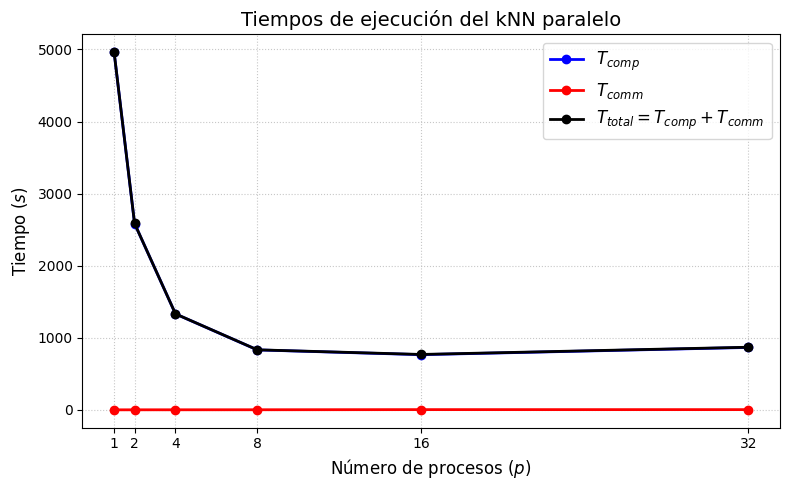

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(df_100['Processes'], df_100['T_comp (s)'], marker='o', linestyle='-', color='b', label='$T_{comp}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_comm (s)'], marker='o', linestyle='-', color='r', label='$T_{comm}$', linewidth=2)
plt.plot(df_100['Processes'], df_100['T_total (s)'], marker='o', linestyle='-', color='black', label='$T_{total} = T_{comp} + T_{comm}$', linewidth=2)

plt.title('Tiempos de ejecución del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Tiempo ($s$)', fontsize=12)
plt.grid(True, linestyle=":", alpha=0.7)
plt.xticks(df_100['Processes'])
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Cómputo $T_{comp}$ vs Comunicación $T_{comm}$

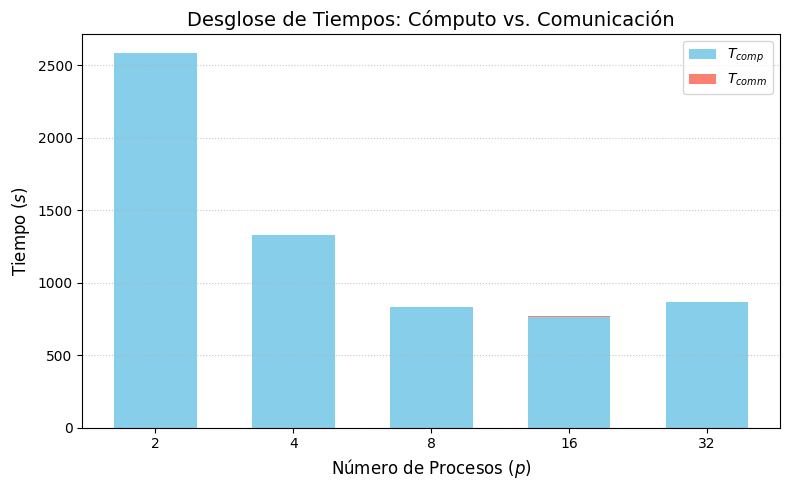

In [7]:
plt.figure(figsize=(8, 5))

df_mpi = df_100[df_100['Processes'] > 1]
x_labels_bar = df_mpi['Processes'].astype(str)

plt.bar(x_labels_bar, df_mpi['T_comp (s)'], color='skyblue', label='$T_{comp}$', width=0.6)
plt.bar(x_labels_bar, df_mpi['T_comm (s)'], bottom=df_mpi['T_comp (s)'], color='salmon', label='$T_{comm}$', width=0.6)

plt.title('Desglose de Tiempos: Cómputo vs. Comunicación', fontsize=14)
plt.xlabel('Número de Procesos ($p$)', fontsize=12)
plt.ylabel('Tiempo ($s$)', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Accuracy del kNN paralelo

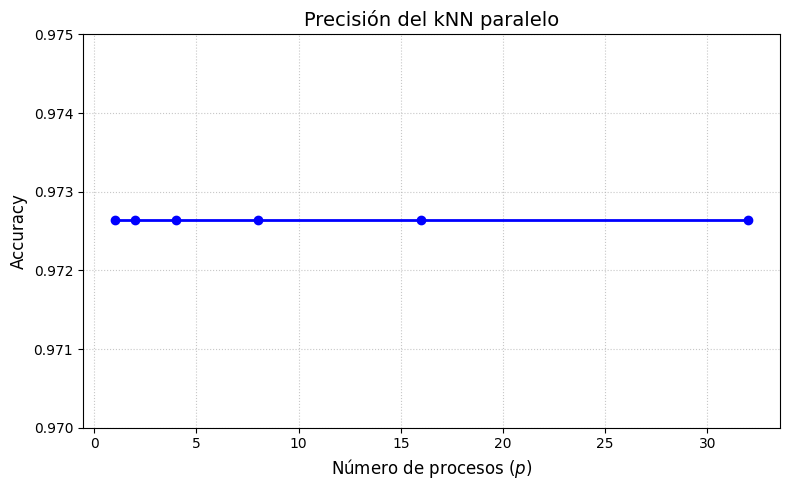

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(df_100['Processes'], df_100['Accuracy'], marker='o', linestyle='-', color='b', linewidth=2)

plt.title('Precisión del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.ylim(0.97, 0.975)

plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

### Cálculo del Speedup $S = T_s / T_p$

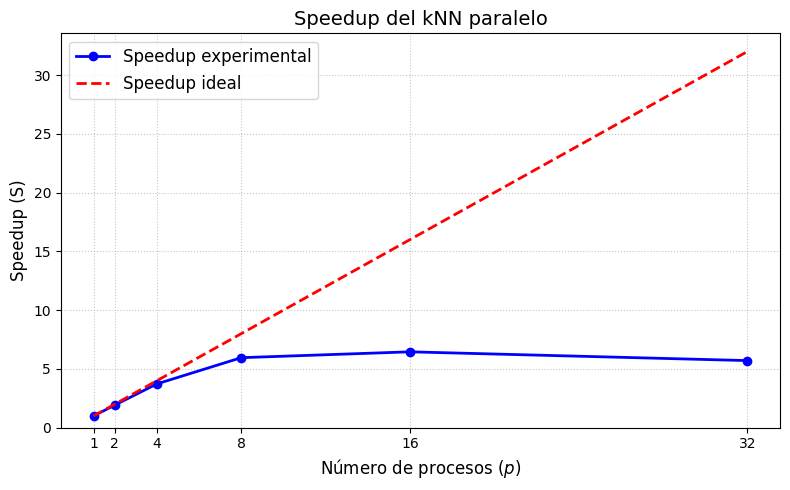

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['Speedup'], marker='o', linestyle='-', color='b', label='Speedup experimental', linewidth=2)
plt.plot(df_100['Processes'], df_100['Processes'], marker='', linestyle='--', color='r', label='Speedup ideal', linewidth=2)

plt.title('Speedup del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('Speedup (S)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.ylim(bottom=0)
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### FLOP/s de ejecución del kNN

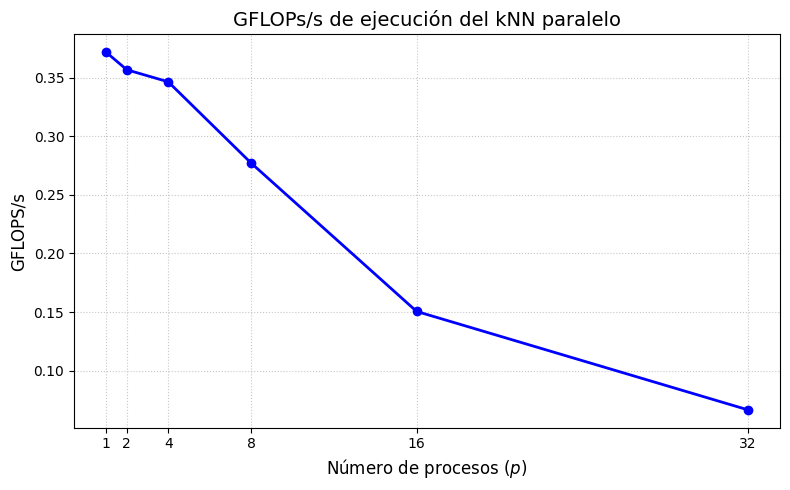

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['GFLOP/s'], marker='o', linestyle='-', color='b', linewidth=2)

plt.title('GFLOPs/s de ejecución del kNN paralelo', fontsize=14)
plt.xlabel('Número de procesos ($p$)', fontsize=12)
plt.ylabel('GFLOPS/s', fontsize=12)
plt.xticks(df_100['Processes'])
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

### Eficiencia del kNN paralelo

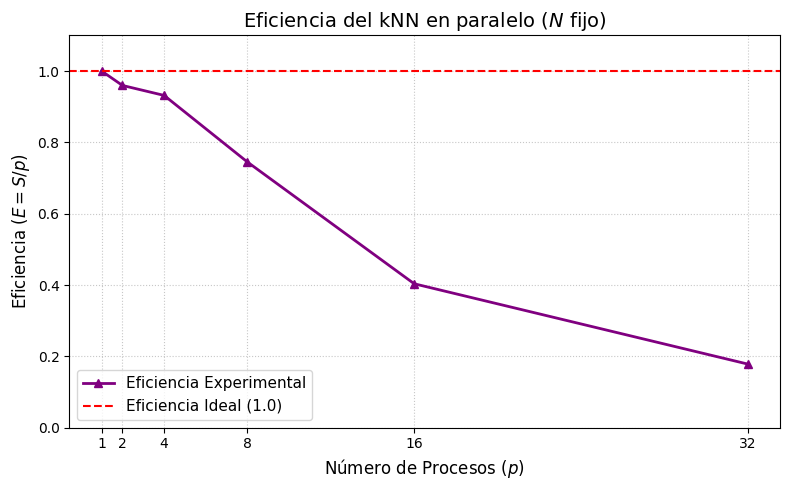

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(df_100['Processes'], df_100['Efficiency'], marker='^', linestyle='-', color='purple', label='Eficiencia Experimental', linewidth=2)
plt.axhline(y=1.0, color='r', linestyle='--', label='Eficiencia Ideal (1.0)')

plt.title('Eficiencia del kNN en paralelo ($N$ fijo)', fontsize=14)
plt.xlabel('Número de Procesos ($p$)', fontsize=12)
plt.ylabel('Eficiencia ($E = S / p$)', fontsize=12)
plt.xticks(df_100['Processes'])
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Gráficas con tamaño ($N$) variable

In [18]:
N = 56000 + 14000
subset_25 = int(N * 0.25)
subset_50 = int(N * 0.50)
subset_75 = int(N * 0.75)

print("N SIZES:")
print(f"- Subset  25%: {subset_25} samples")
print(f"- Subset  50%: {subset_50} samples")
print(f"- Subset  75%: {subset_75} samples")
print(f"- Subset 100%: {N} samples")

N SIZES:
- Subset  25%: 17500 samples
- Subset  50%: 35000 samples
- Subset  75%: 52500 samples
- Subset 100%: 70000 samples


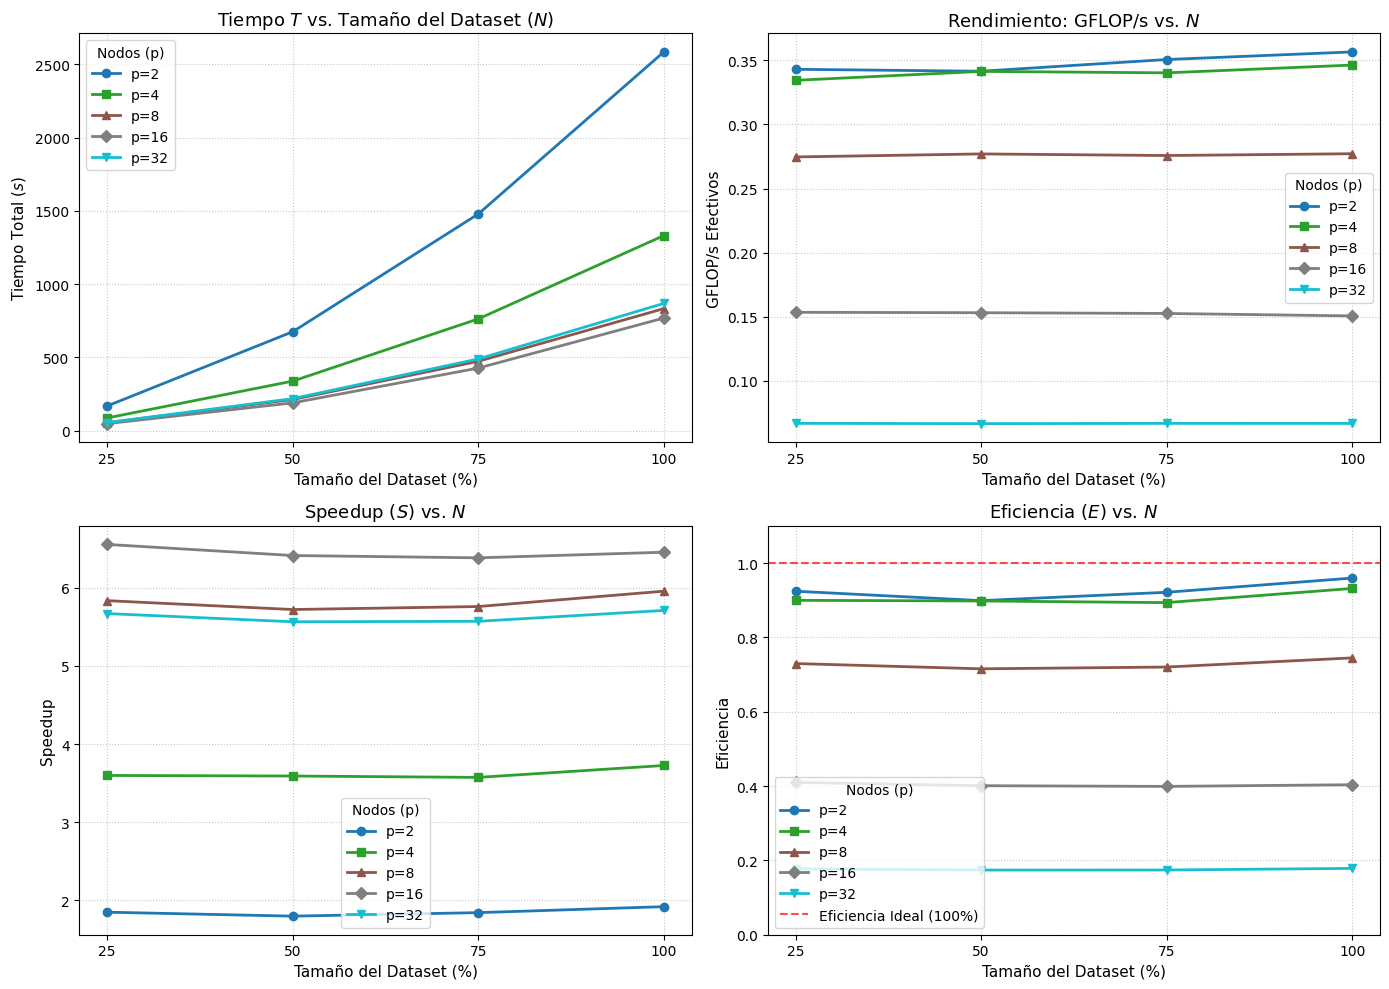

In [16]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

df_mpi_np = df[df['Processes'] > 1]
procesos_unicos = sorted(df_mpi_np['Processes'].unique())

colores = cm.tab10(np.linspace(0, 1, len(procesos_unicos)))
marcadores = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', '<', '>']

for i, p in enumerate(procesos_unicos):
    df_p = df_mpi_np[df_mpi_np['Processes'] == p]
    c = colores[i]
    m = marcadores[i % len(marcadores)]
    
    # ax1: Tiempo Total
    ax1.plot(df_p['Subset_%'], df_p['T_total (s)'], marker=m, color=c, linewidth=2, label=f'p={p}')
    
    # ax2: Rendimiento Bruto
    ax2.plot(df_p['Subset_%'], df_p['GFLOP/s'], marker=m, color=c, linewidth=2, label=f'p={p}')
    
    # ax3: Speedup
    ax3.plot(df_p['Subset_%'], df_p['Speedup'], marker=m, color=c, linewidth=2, label=f'p={p}')
    
    # ax4: Eficiencia
    ax4.plot(df_p['Subset_%'], df_p['Efficiency'], marker=m, color=c, linewidth=2, label=f'p={p}')
    
ax1.set_title('Tiempo $T$ vs. Tamaño del Dataset ($N$)', fontsize=13)
ax1.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax1.set_ylabel('Tiempo Total ($s$)', fontsize=11)
ax1.set_xticks([25, 50, 75, 100])
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(title='Nodos (p)')

ax2.set_title('Rendimiento: GFLOP/s vs. $N$', fontsize=13)
ax2.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax2.set_ylabel('GFLOP/s Efectivos', fontsize=11)
ax2.set_xticks([25, 50, 75, 100])
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(title='Nodos (p)')

ax3.set_title('Speedup ($S$) vs. $N$', fontsize=13)
ax3.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax3.set_ylabel('Speedup', fontsize=11)
ax3.set_xticks([25, 50, 75, 100])
ax3.grid(True, linestyle=':', alpha=0.7)
ax3.legend(title='Nodos (p)')

ax4.axhline(y=1.0, color='red', linestyle='--', label='Eficiencia Ideal (100%)', alpha=0.7)
ax4.set_title('Eficiencia ($E$) vs. $N$', fontsize=13)
ax4.set_xlabel('Tamaño del Dataset (%)', fontsize=11)
ax4.set_ylabel('Eficiencia', fontsize=11)
ax4.set_xticks([25, 50, 75, 100])
ax4.set_ylim(0, 1.1)
ax4.grid(True, linestyle=':', alpha=0.7)
ax4.legend(title='Nodos (p)')

plt.tight_layout()
plt.show()